##Scrapping Google Apps Review - eg Mobile JKN
Week 2 NLP Pipeline PBA/ Genap 2025/ Irmasari Hafidz irma@its.ac.id

In [1]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.1 MB/s eta 0:00:00


In [2]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

In [10]:
#Android App Mobile JKN  from Google Play at
#https://play.google.com/store/apps/details?id=app.bpjs.mobile&hl=id
#ID Apps:
#The apps ID found in the link after id=app.bpjs.mobile&hl=id
#The apps name on Google Play titled: MobileJKN dari Pemerintah Indonesia (Kemenkes)
#Dated 3 March 2025 and N of reviews 787K

from google_play_scraper import app, Sort, reviews_all

cis_reviews = reviews_all(
    'info.pdamsby.go.id.pdam',
    sleep_milliseconds=0, # defaults to 0
    lang='en', # defaults to 'en'
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

In [12]:
#Save Mobile JKN reviews into dataframe
df_cisrev = pd.DataFrame(np.array(cis_reviews),columns=['content'])
df_cisrev = df_cisrev.join(pd.DataFrame(df_cisrev.pop('content').tolist()))
df_cisrev.to_csv(r'df_cisrev', index=False)

## Homework TUGAS 1A

NLP Pipeline:
RAW data (save to csv) lakukan:

* Tokenization
* Lowering
* Stopword Removal
* Lemmatization
* Stemming
* Punctuations Removal
* Expand Contractions
* Spelling Correction
* Rare Words Removal
* Common Words Removal

(save as cleandata.csv)
* Frequent words (n=50,100,1000)
* Frequent Words found (new), contoh: yg, bs, tyt
* ditambahkan di stopwords removal
* Stopwords removal (NLTK, misal case study review hanya dalam Indonesia n=758)


In [13]:
df_cisrev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,e247ae20-d9e0-4dc0-9903-54af1569681f,Imelda Kristianti,https://play-lh.googleusercontent.com/a-/ALV-U...,"abis update malah ga muncul apa², dan terus²an...",1,0,6.10.0,2026-03-04 13:21:57,None,NaT,6.10.0
1,cb66d30d-d518-4463-a4ed-3d558d6fea4c,Boby Gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,Upload versi terbaru tidak bisa di buka???,1,0,6.10.0,2026-03-04 03:55:16,None,NaT,6.10.0
2,6f0c8d48-24db-461a-88ef-5a2811226961,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,untuk cek mandiri di bulan Maret ini tiba2 ngg...,3,2,6.10.0,2026-03-03 08:14:26,None,NaT,6.10.0
3,cd93882a-3425-46eb-995d-275106d1f2dc,ardyan novanto,https://play-lh.googleusercontent.com/a-/ALV-U...,setelah update terbaru dan info gangguan serve...,2,0,6.10.0,2026-02-26 08:12:32,None,NaT,6.10.0
4,05bb3a43-d1af-4f69-8157-ec1ae63c6c3e,Hendra Gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,ini app kenapa tidak bisa login ya? dibuka han...,1,1,6.10.0,2026-02-26 02:21:40,None,NaT,6.10.0
...,...,...,...,...,...,...,...,...,...,...,...
401,c0165aef-6ee1-4bd3-9a0d-ab38d14217ee,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,APLIKASI,5,0,1.4,2014-01-21 06:38:52,None,NaT,1.4
402,3800e16b-325c-48a4-9c2c-af6411ccb582,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Josss sangat membantu,5,0,1.4,2014-01-16 15:12:20,None,NaT,1.4
403,9016a408-ca22-4924-b323-1aae1ad926c3,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Helpfull,3,0,1.4,2013-12-14 05:19:37,None,NaT,1.4
404,8d77065b-bf46-494c-8db3-4b231fb7c770,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasinya sip!,5,0,1.3,2013-11-16 11:55:27,None,NaT,1.3


In [14]:
df_cisrev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              406 non-null    object        
 1   userName              406 non-null    object        
 2   userImage             406 non-null    object        
 3   content               405 non-null    object        
 4   score                 406 non-null    int64         
 5   thumbsUpCount         406 non-null    int64         
 6   reviewCreatedVersion  371 non-null    object        
 7   at                    406 non-null    datetime64[ns]
 8   replyContent          88 non-null     object        
 9   repliedAt             88 non-null     datetime64[ns]
 10  appVersion            371 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 35.0+ KB


In [15]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_analysis = df_cisrev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

In [ ]:
#Check number of reviews scores
df_jknrev['score'].value_counts()

,count
score,
1,11813
5,10142
2,1802
4,1511
3,1433


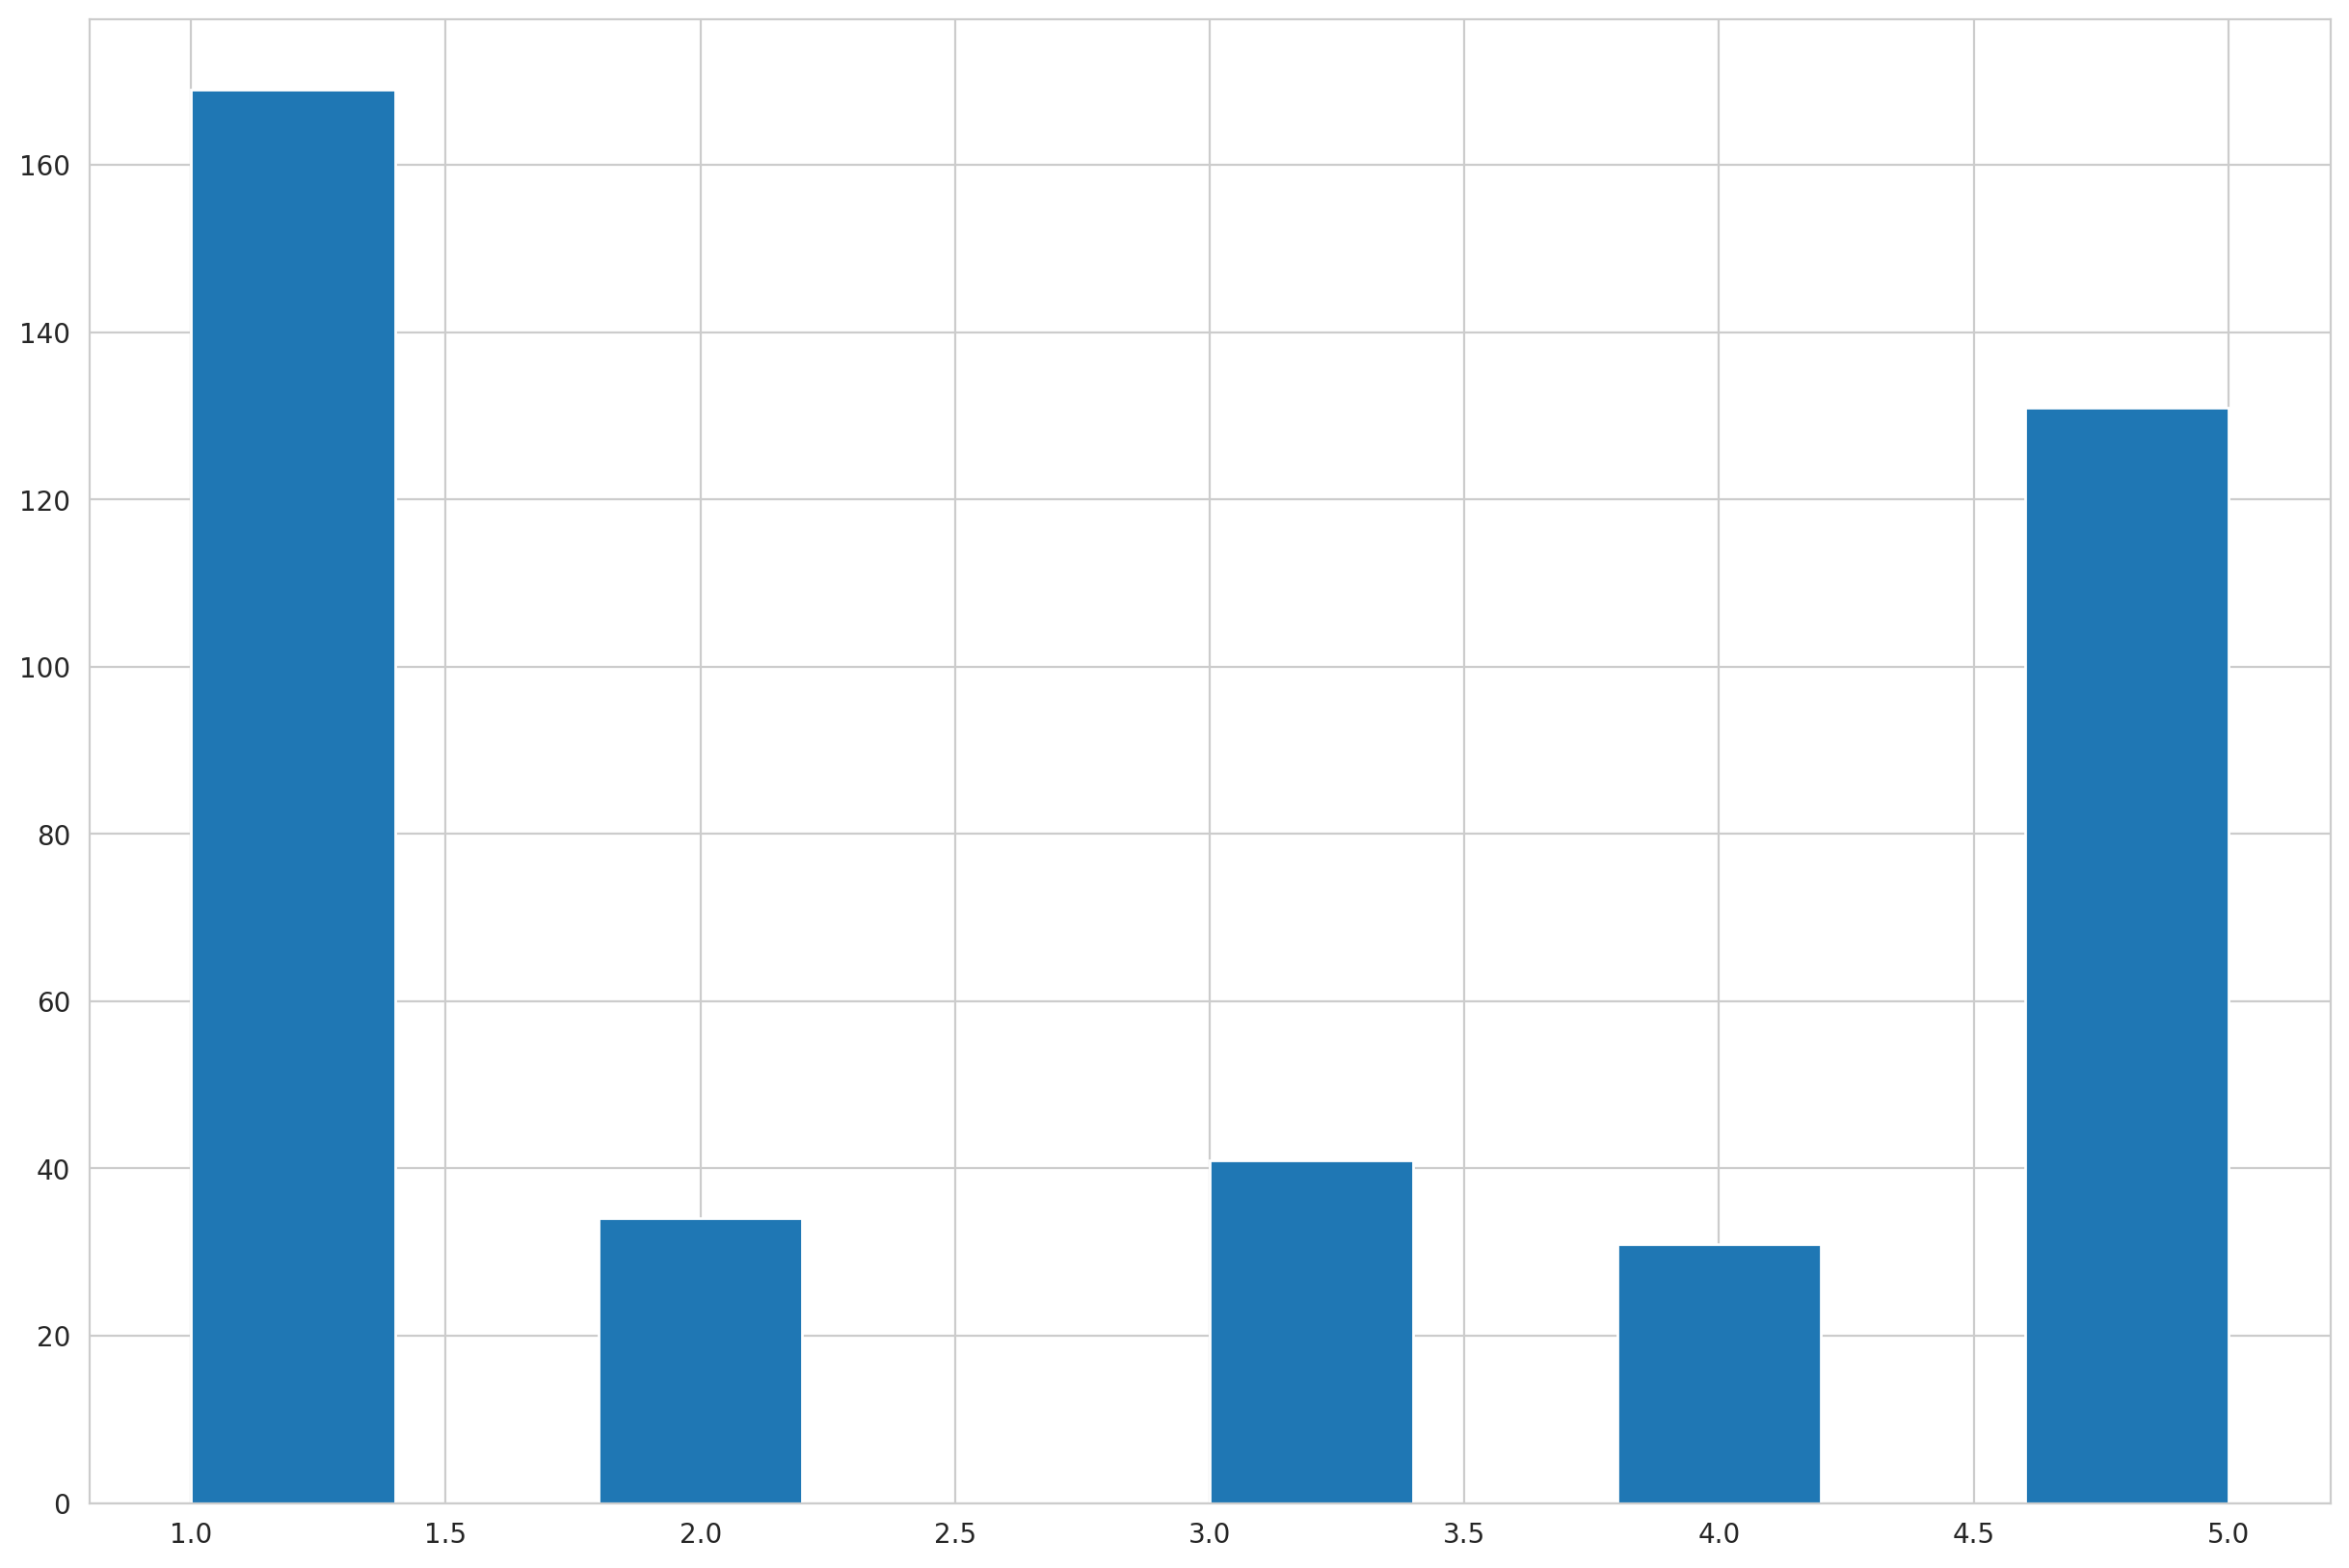

In [16]:
plt.hist(df_cisrev['score'])
plt.show()

In [17]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.6 MB/s eta 0:00:00


In [18]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
# Handle None values in 'content' column by replacing them with empty strings
df_cisrev['sentiment_polarity'] = df_cisrev['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_cisrev['sentiment_subjective'] = df_cisrev['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

In [19]:
df_cisrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,"abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...",1,0.0,0.0
1,Upload versi terbaru tidak bisa di buka???,1,0.0,0.0
2,untuk cek mandiri di bulan Maret ini tiba2 ngga bs login pakai no HP OTP nya tidak terkirim meski dicoba beberapa kali.,3,0.0,0.0
3,"setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak",2,0.0,0.0
4,ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi,1,0.0,0.0
...,...,...,...,...
401,APLIKASI,5,0.0,0.0
402,Josss sangat membantu,5,0.0,0.0
403,Helpfull,3,0.0,0.0
404,Aplikasinya sip!,5,0.0,0.0


## Lowercasing

In [ ]:
#DATA PREPROCESSING
# Lower casing
# Change the reviews type to string
df_cisrev['content'] = df_cisrev['content'].astype(str)# Before lowercasing
# Before lowercasing
print(df_cisrev['content'][188])
print(df_cisrev['content'][1])
print(df_cisrev['content'][20100])

Gini amat yak hasil duit pajak, verif wajah gapernah bisa, otp gapernah kekirim
kenapa susah sekali utk login. saya udah bayar lebih dr 2 th rp. 150.000 perbulan???
Gak bisa digunakan


In [21]:
#Lowercase all reviews to see the difference
df_cisrev['content']= df_cisrev['content'].fillna('').apply(lambda x: x.lower())
print(df_cisrev['content'][188])
print(df_cisrev['content'][1])
print(df_cisrev['content'][400])

app was freeze, can not do anything.
upload versi terbaru tidak bisa di buka???



##Stopwords Removal
Indonesian Stopwords

In [22]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian')

# Display first 20 stopwords
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [23]:
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_cisrev['wordCount'] = [len(review.split()) for review in df_cisrev['content']]
df_cisrev['uppercaseCharCount'] = [sum(char.isupper() for char in review) \
                              for review in df_cisrev['content']]
df_cisrev['specialCharCount'] = [sum(char in string.punctuation for char in review) \
                            for review in df_cisrev['content']]

In [24]:
df_cisrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,"abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...",1,0.0,0.0,11,0,4
1,upload versi terbaru tidak bisa di buka???,1,0.0,0.0,7,0,3
2,untuk cek mandiri di bulan maret ini tiba2 ngga bs login pakai no hp otp nya tidak terkirim meski dicoba beberapa kali.,3,0.0,0.0,22,0,1
3,"setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak",2,0.0,0.0,19,0,2
4,ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi,1,0.0,0.0,14,0,1
...,...,...,...,...,...,...,...
401,aplikasi,5,0.0,0.0,1,0,0
402,josss sangat membantu,5,0.0,0.0,3,0,0
403,helpfull,3,0.0,0.0,1,0,0
404,aplikasinya sip!,5,0.0,0.0,2,0,1


In [25]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_cisrev['sentiment_rating'] = df_cisrev['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [26]:
df_cisrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...",1,0.0,0.0,Negative
1,upload versi terbaru tidak bisa di buka???,1,0.0,0.0,Negative
2,untuk cek mandiri di bulan maret ini tiba2 ngga bs login pakai no hp otp nya tidak terkirim meski dicoba beberapa kali.,3,0.0,0.0,Neutral
3,"setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak",2,0.0,0.0,Negative
4,ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi,1,0.0,0.0,Negative
...,...,...,...,...,...
401,aplikasi,5,0.0,0.0,Positive
402,josss sangat membantu,5,0.0,0.0,Positive
403,helpfull,3,0.0,0.0,Neutral
404,aplikasinya sip!,5,0.0,0.0,Positive


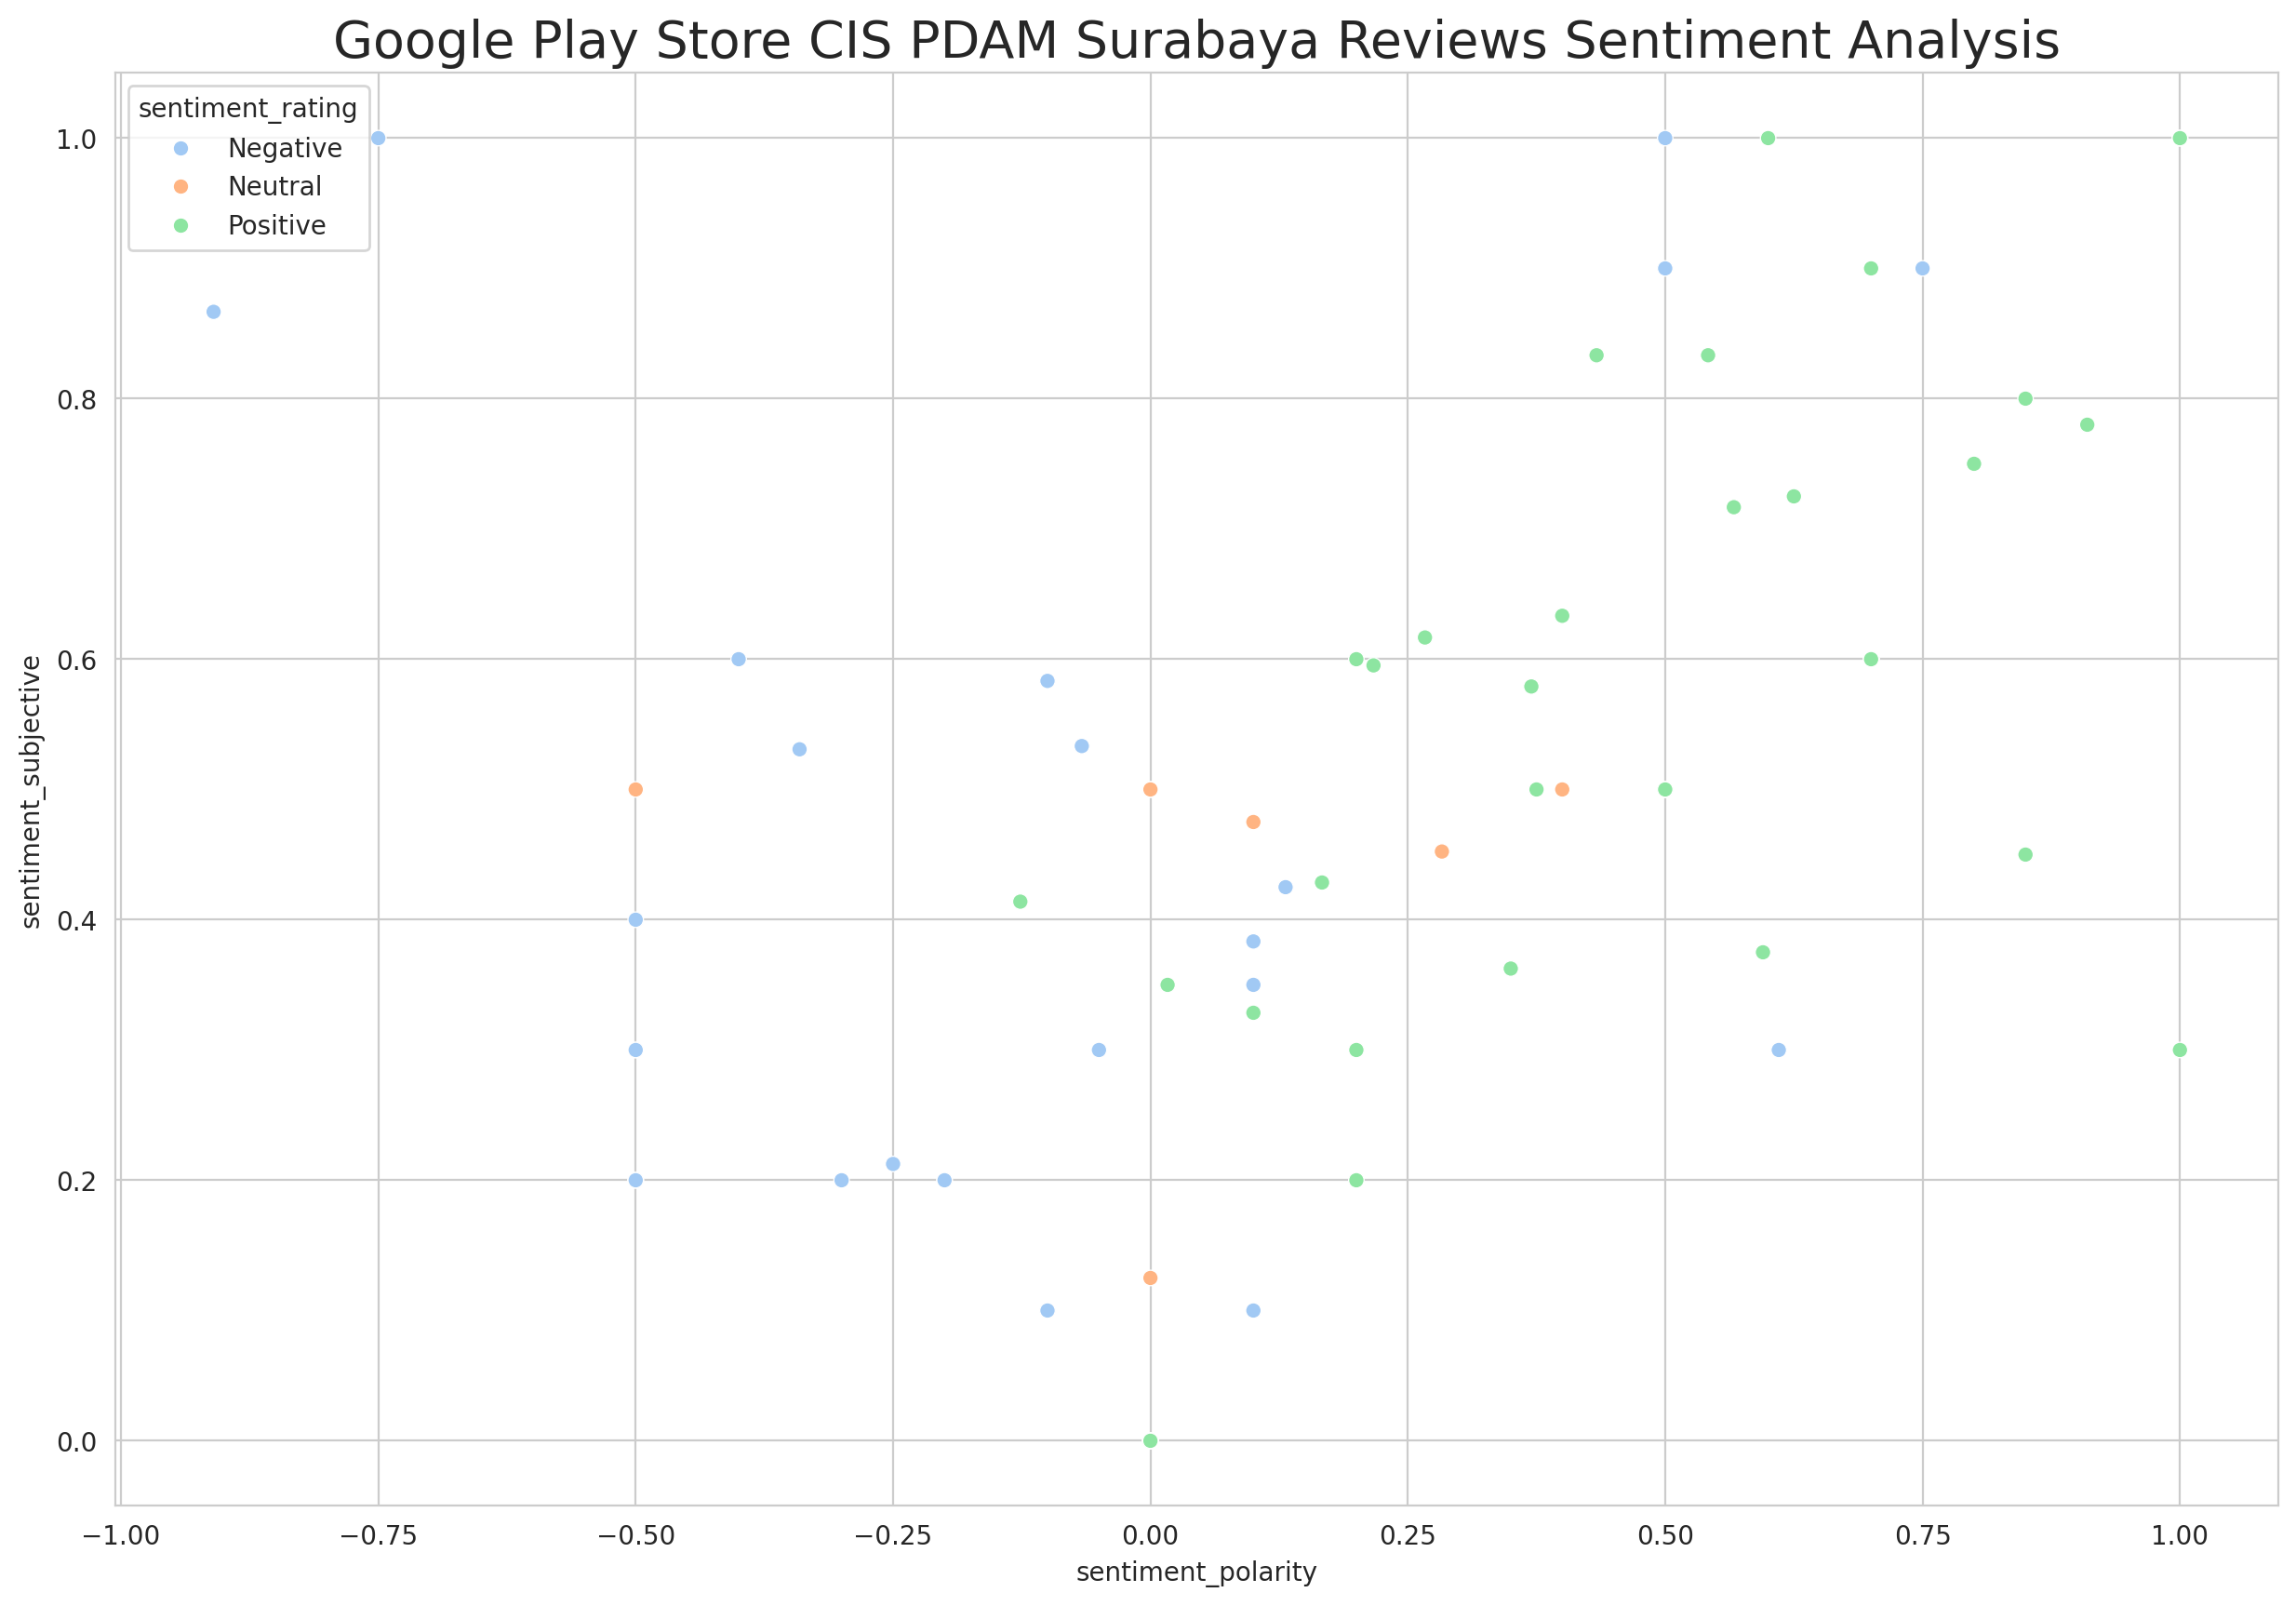

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
# Specify x and y using the 'x' and 'y' parameters within sns.scatterplot
sns.scatterplot(x=df_cisrev['sentiment_polarity'], y=df_cisrev['sentiment_subjective'],
                hue=df_cisrev['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store CIS PDAM Surabaya Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [29]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

/tmp/ipykernel_238/2152088084.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


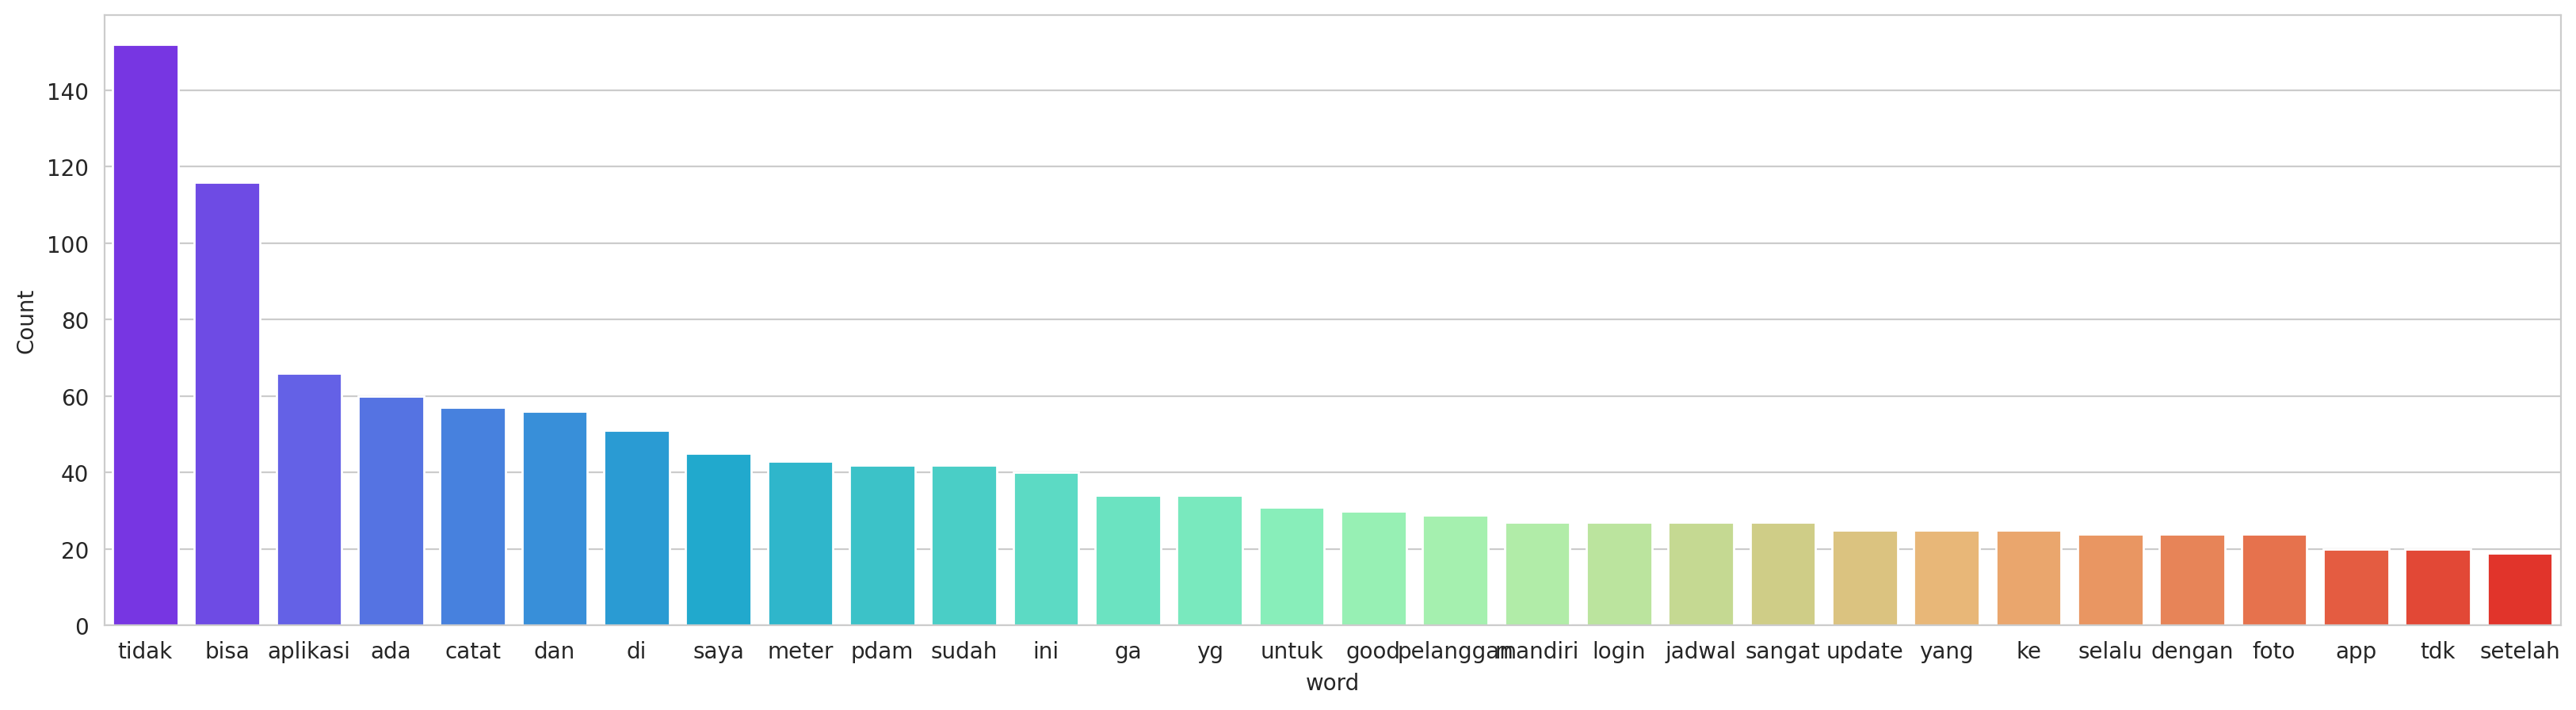

In [30]:
freq_words(df_cisrev['content'])

In [31]:
# prompt: the [content] column hasnt been applied Indonesian stopwords removal using Sastrawi

!pip install Sastrawi

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Create stopword remover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Apply stopword removal to the 'content' column
df_cisrev['content'] = df_cisrev['content'].apply(lambda x: stopword_remover.remove(x))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00


In [32]:
# prompt: can you also apply English stopwords as well to the [content] column

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get English stopwords
english_stopwords = stopwords.words('english')

# Assuming df_jknrev is your DataFrame and 'content' is the column
df_cisrev['content'] = df_cisrev['content'].apply(lambda x: ' '.join([word for word in x.split() if word not in english_stopwords]))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
english_stopwords(len)

NameError: name 'english_stopwords' is not defined

In [33]:
df_cisrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"abis update malah ga muncul apa², terus²an memeriksa koneksi anda...",1,0.0,0.0,Negative
1,upload versi terbaru bisa buka???,1,0.0,0.0,Negative
2,cek mandiri bulan maret tiba2 ngga bs login pakai hp otp nya terkirim meski dicoba beberapa kali.,3,0.0,0.0,Neutral
3,"update terbaru info gangguan server, sekarang stabil. cek history tagihan aja kadang tampil kadang",2,0.0,0.0,Negative
4,app tidak login ya? dibuka muter2 tulisan memeriksa koneksi,1,0.0,0.0,Negative
...,...,...,...,...,...
401,aplikasi,5,0.0,0.0,Positive
402,josss sangat membantu,5,0.0,0.0,Positive
403,helpfull,3,0.0,0.0,Neutral
404,aplikasinya sip!,5,0.0,0.0,Positive


In [34]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

/tmp/ipykernel_238/2152088084.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


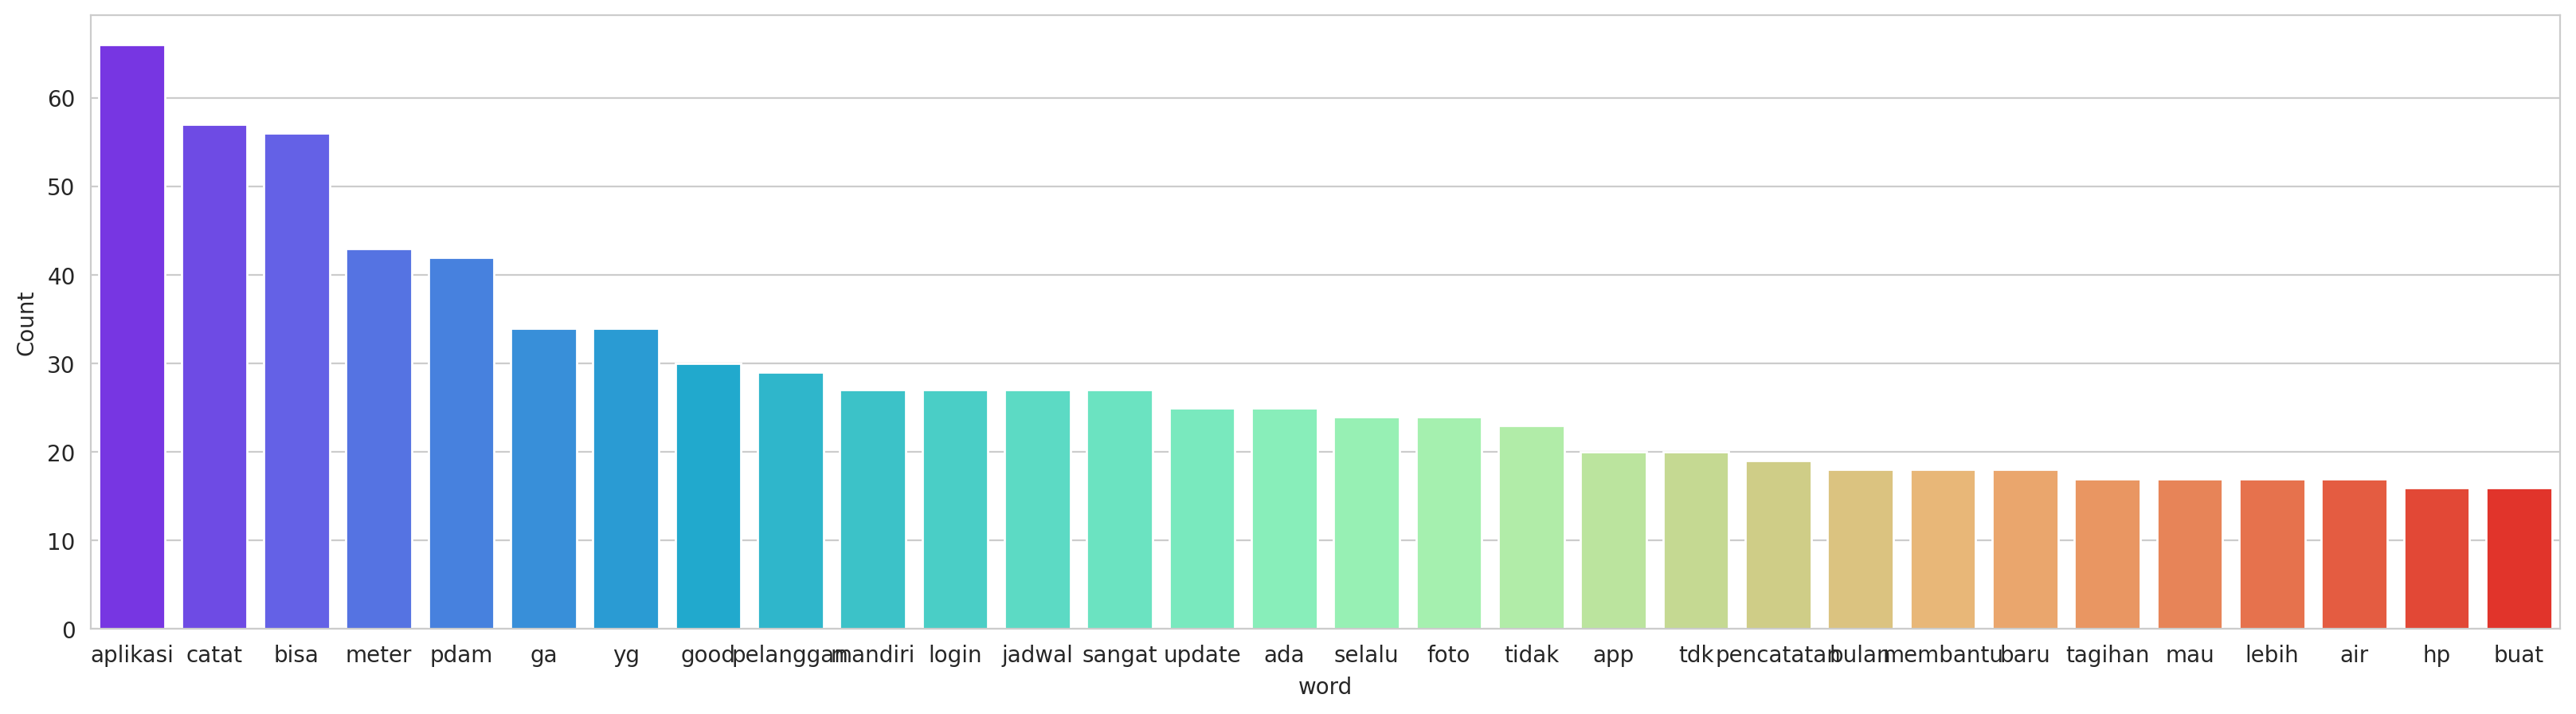

In [35]:
freq_words(df_cisrev['content'])

In [37]:
#Count after stopwords
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

# The 'content' column in df_cisrev already contains the text after stopword removal.
# Calculate the word count for the processed content and store it in a new column.
df_cisrev['wordCount_after_stopwords'] = [len(review.split()) for review in df_cisrev['content']]
